# Feature engineering: employee engagement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/employee_engagement.csv')
print(f'Original features: {df.shape[1]}')
df['recognition_ratio'] = df['recognition_events_received'] / (df['recognition_events_given'] + 1)
df['tenure_group'] = pd.cut(df['tenure_months'], bins=[0,6,12,24,60,120], labels=['<6mo','6-12mo','1-2yr','2-5yr','5yr+'])
df['engagement_gap'] = df['engagement_score'] - (df['satisfaction_survey'] * 2)
df['total_recognition'] = df['recognition_events_received'] + df['recognition_events_given']
df['absenteeism_rate'] = df['absenteeism_days'] / (df['tenure_months'] + 1)
print(f'After engineering: {df.shape[1]} features')
df[['recognition_ratio','engagement_gap','total_recognition','absenteeism_rate']].describe().round(2)

Original features: 14
After engineering: 19 features


,recognition_ratio,engagement_gap,total_recognition,absenteeism_rate
count,8000.00,7950.00,8000.00,8000.00
mean,2.08,-1.22,10.18,0.46
std,1.60,1.34,5.50,0.89
min,0.00,-6.40,0.00,0.00
25%,1.00,-2.10,6.00,0.07
50%,1.67,-1.20,9.00,0.13
75%,2.60,-0.30,14.00,0.33
max,17.00,3.70,32.00,8.50


C:\Users\User\AppData\Local\Temp\ipykernel_17996\1108395857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['is_disengaged'].mean().plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
C:\Users\User\AppData\Local\Temp\ipykernel_17996\1108395857.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_disengaged', y='recognition_ratio', ax=axes[1], palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_17996\1108395857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Engaged','Disengag

C:\Users\User\AppData\Local\Temp\ipykernel_17996\1108395857.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_disengaged', y='absenteeism_rate', ax=axes[2], palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_17996\1108395857.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Engaged','Disengaged'])


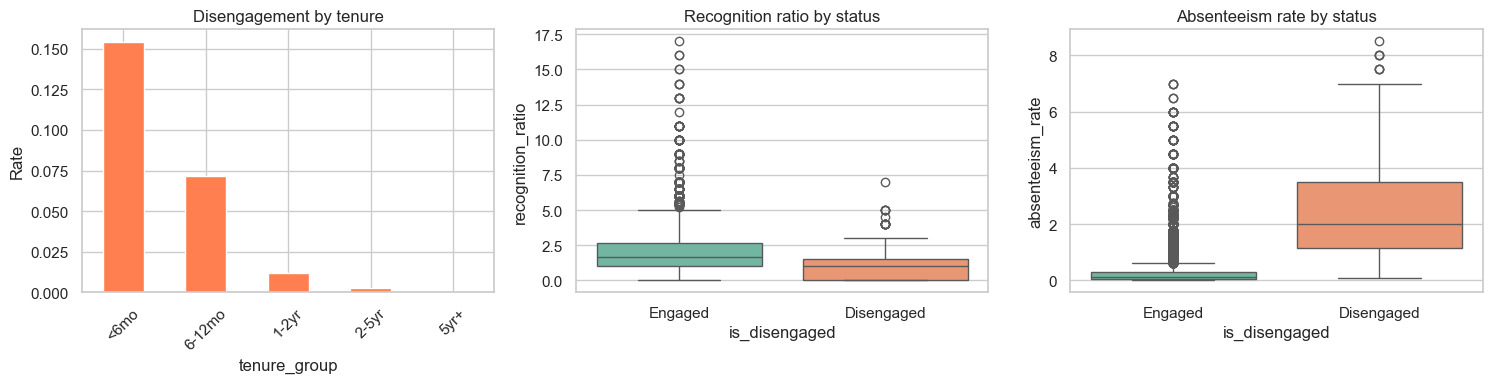

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.groupby('tenure_group')['is_disengaged'].mean().plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Disengagement by tenure')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=df, x='is_disengaged', y='recognition_ratio', ax=axes[1], palette='Set2')
axes[1].set_title('Recognition ratio by status')
axes[1].set_xticklabels(['Engaged','Disengaged'])
sns.boxplot(data=df, x='is_disengaged', y='absenteeism_rate', ax=axes[2], palette='Set2')
axes[2].set_title('Absenteeism rate by status')
axes[2].set_xticklabels(['Engaged','Disengaged'])
plt.tight_layout()
plt.show()